In [2]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras


In [3]:
housing = fetch_california_housing(as_frame=True)
df =  housing.frame
print("Shape", df.shape)
print("Columns", df.columns.tolist())
df.head()

Shape (20640, 9)
Columns ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


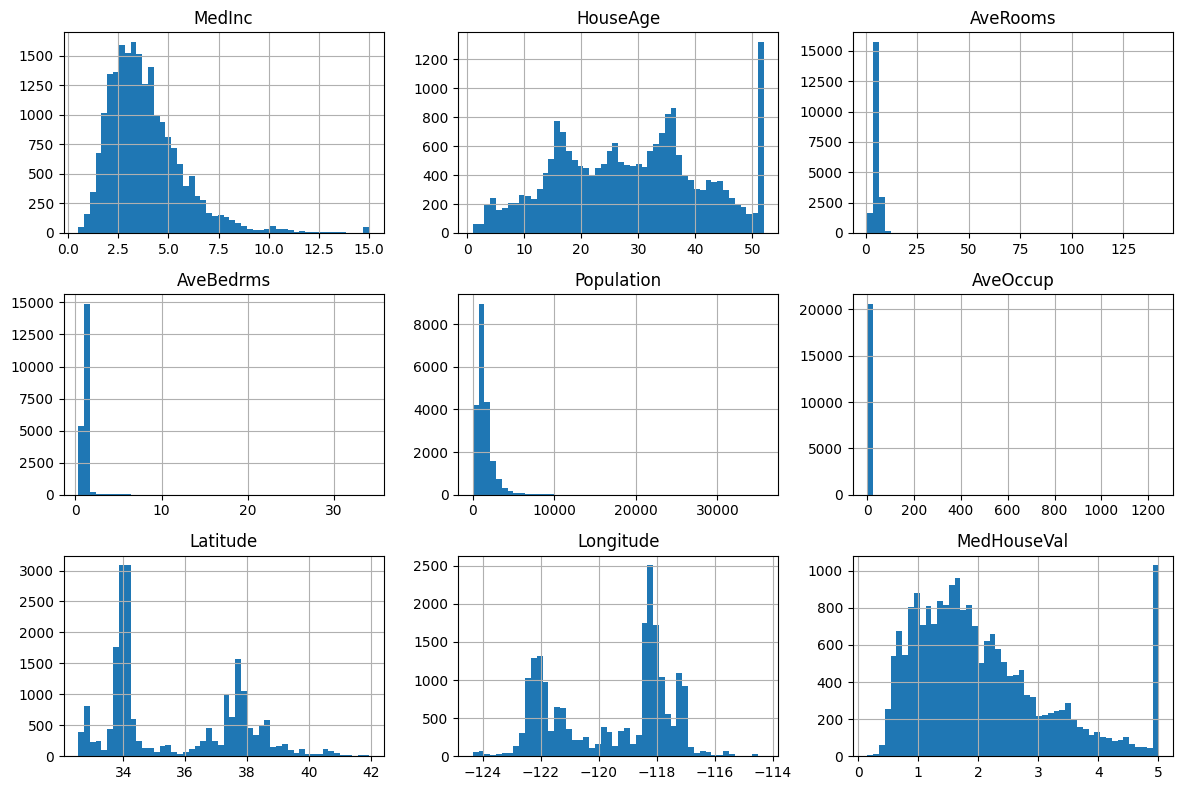

In [6]:
df.hist(figsize=(12, 8), bins=50)
plt.tight_layout()
plt.show()

In [7]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst few targets:", y.head().values)

X shape: (20640, 8)
y shape: (20640,)

First few targets: [4.526 3.585 3.521 3.413 3.422]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [9]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - Population mean:", X_train['Population'].mean().round(2))
print("After scaling  - Population mean:", X_train_scaled[:, 4].mean().round(4))
print("After scaling  - Population std: ", X_train_scaled[:, 4].std().round(4))

Before scaling - Population mean: 1426.45
After scaling  - Population mean: -0.0
After scaling  - Population std:  1.0


In [10]:
# from tensorflow import keras
# from tensorflow.keras import layers

# model = keras.Sequential([
#     layers.Input(shape=(8,)),
#     layers.Dense(64, activation='tanh'),
#     layers.Dense(32, activation='tanh'),
#     layers.Dense(1)
# ])

# model.summary()

In [11]:
# from tensorflow import keras
# from tensorflow.keras import layers

# model = keras.Sequential([
#     layers.Input(shape=(8,)),
#     layers.Dense(16, activation='tanh'),
#     layers.Dense(1)
# ])

# model.summary()

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(16, activation='tanh'),
    layers.Dense(8, activation='tanh'),
    layers.Dense(16, activation='tanh'),
    layers.Dense(8, activation='tanh'),
    layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569 (2.22 KB)

 Trainable params: 569 (2.22 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Model compiled successfully")

Model compiled successfully


In [13]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.2950 - mae: 0.8172 - val_loss: 0.6469 - val_mae: 0.6077
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5348 - mae: 0.5433 - val_loss: 0.5272 - val_mae: 0.5359
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.4595 - mae: 0.4983 - val_loss: 0.4667 - val_mae: 0.4912
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.4168 - mae: 0.4671 - val_loss: 0.4423 - val_mae: 0.4863
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3924 - mae: 0.4478 - val_loss: 0.4198 - val_mae: 0.4576
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3742 - mae: 0.4341 - val_loss: 0.4034 - val_mae: 0.4359
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3586 - mae: 0.4222 - val_loss: 0.3930 - val_mae: 0.4302
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3487 - mae: 0.4154 - val_loss: 0.3933 - val_mae: 0.4308
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

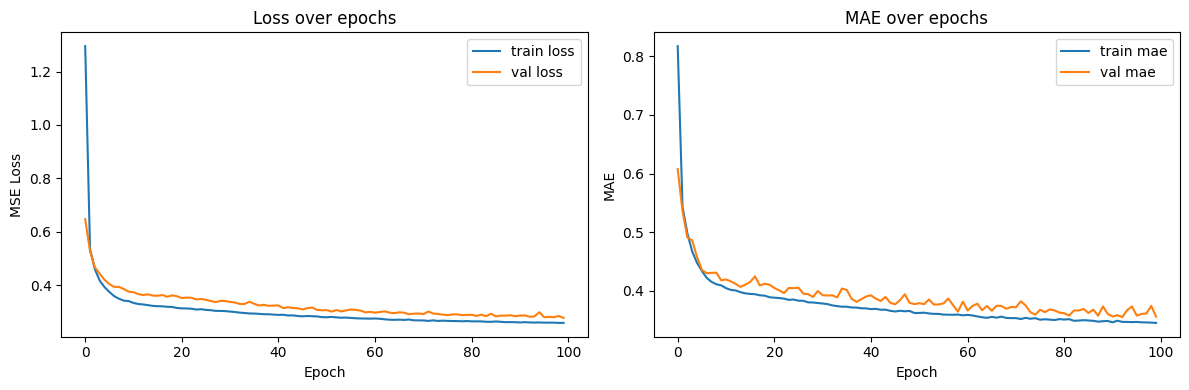

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='val mae')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('MAE over epochs')
plt.legend()

plt.tight_layout()
plt.show()

Test MAE: 0.3501
That means on average we are off by $35010
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


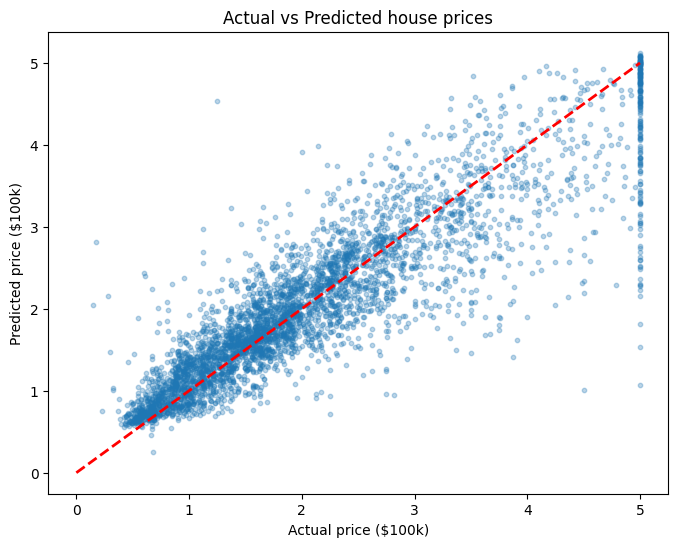

In [15]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test MAE: {test_mae:.4f}")
print(f"That means on average we are off by ${test_mae * 100000:.0f}")

y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)
plt.xlabel('Actual price ($100k)')
plt.ylabel('Predicted price ($100k)')
plt.title('Actual vs Predicted house prices')
plt.show()